<a href="https://colab.research.google.com/github/vanshikag050-bit/Student-Performance-Predictor/blob/main/FakeNewsDetector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, classification_report, ConfusionMatrixDisplay)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
n = 1000

df = pd.DataFrame({
    "study_hours_per_week": rng.normal(12, 5, n).clip(0, 35),
    "attendance_pct":       rng.normal(85, 10, n).clip(40, 100),
    "previous_grade":       rng.normal(65, 14, n).clip(0, 100),
    "sleep_hours":          rng.normal(7, 1.2, n).clip(3, 10),
    "absences":             rng.poisson(5, n),
    "parental_support":     rng.choice(["low", "medium", "high"], n, p=[.2, .5, .3]),
    "internet_access":      rng.choice(["yes", "no"], n, p=[.85, .15]),
    "extracurriculars":     rng.choice(["yes", "no"], n, p=[.5, .5]),
    "tutoring":             rng.choice(["yes", "no"], n, p=[.25, .75]),
})

support_bonus = df["parental_support"].map({"low": -3, "medium": 0, "high": 3})
score = (0.35*df["previous_grade"] + 1.1*df["study_hours_per_week"] + 0.2*df["attendance_pct"]
         + 1.0*(df["sleep_hours"]-7) - 0.6*df["absences"] + support_bonus
         + 2*(df["tutoring"]=="yes") + 1.5*(df["internet_access"]=="yes")
         - 1.0*(df["extracurriculars"]=="yes") + rng.normal(0, 4, n))
df["final_score"] = ((score - score.min())/(score.max()-score.min())*100).round(1)
df["passed"] = (df["final_score"] >= 50).astype(int)
df.head()

,study_hours_per_week,attendance_pct,previous_grade,sleep_hours,absences,parental_support,internet_access,extracurriculars,tutoring,final_score,passed
0,13.523585,84.407174,58.672686,8.498827,6,medium,yes,no,no,53.6,1
1,6.800079,77.707131,55.677712,7.825231,6,medium,yes,no,yes,39.5,0
2,15.752256,80.855269,71.076138,9.359353,8,medium,yes,yes,no,45.7,0
3,16.702824,91.339104,68.525962,5.142601,8,medium,yes,yes,no,46.5,0
4,2.244824,85.029933,45.332918,6.681568,9,medium,yes,no,no,15.1,0


In [ ]:
print(df.shape); display(df.describe().T)
print("Pass rate:", df["passed"].mean().round(3))
print("Missing values:", df.isna().sum().sum())

(1000, 11)


,count,mean,std,min,25%,50%,75%,max
study_hours_per_week,1000.0,11.870903,4.903204,0.000000,8.518435,12.030889,14.949434,27.894268
attendance_pct,1000.0,83.940563,9.656307,54.523674,77.697458,84.562151,91.027236,100.000000
previous_grade,1000.0,65.443203,14.159364,22.107082,55.753107,65.513004,75.164649,100.000000
sleep_hours,1000.0,6.995108,1.162886,3.700678,6.174657,6.989672,7.774886,10.000000
absences,1000.0,4.947000,2.276703,0.000000,3.000000,5.000000,6.000000,14.000000
final_score,1000.0,46.662800,15.211377,0.000000,36.200000,46.200000,56.900000,100.000000
passed,1000.0,0.409000,0.491895,0.000000,0.000000,0.000000,1.000000,1.000000


Pass rate: 0.409
Missing values: 0


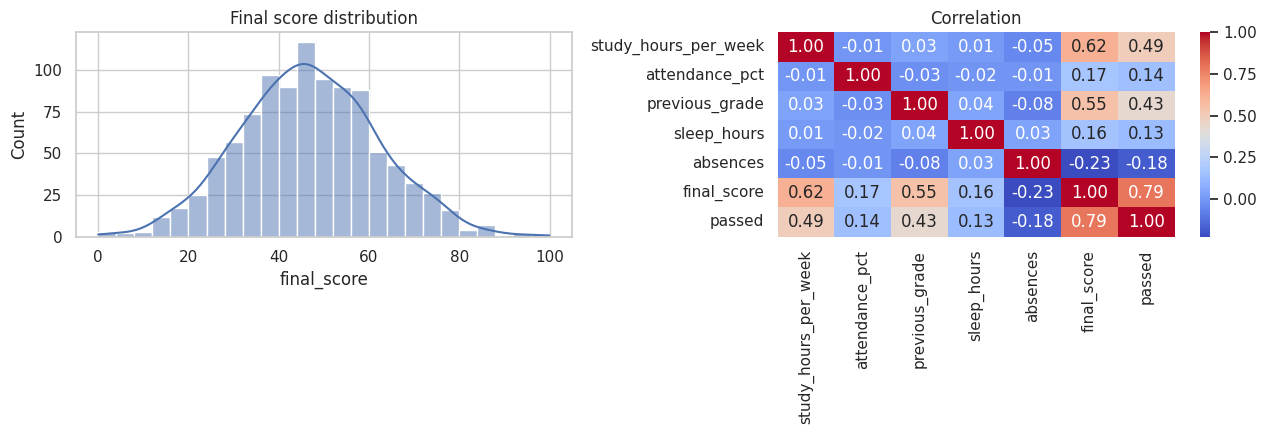

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["final_score"], kde=True, ax=ax[0]); ax[0].set_title("Final score distribution")
sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax[1])
ax[1].set_title("Correlation"); plt.tight_layout(); plt.show()

In [ ]:
num_cols = ["study_hours_per_week","attendance_pct","previous_grade","sleep_hours","absences"]
cat_cols = ["parental_support","internet_access","extracurriculars","tutoring"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols),
])

X = df[num_cols + cat_cols]
y_reg, y_clf = df["final_score"], df["passed"]
X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)
print(X_train.shape, X_test.shape)

(800, 9) (200, 9)


In [ ]:
reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}
rows, fitted_reg = [], {}
for name, model in reg_models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    cv_r2 = cross_val_score(pipe, X_train, yr_train, cv=5, scoring="r2").mean()
    pipe.fit(X_train, yr_train); pred = pipe.predict(X_test)
    fitted_reg[name] = pipe
    rows.append({"Model": name, "CV R²": cv_r2, "Test R²": r2_score(yr_test, pred),
                 "MAE": mean_absolute_error(yr_test, pred),
                 "RMSE": np.sqrt(mean_squared_error(yr_test, pred))})
results = pd.DataFrame(rows).set_index("Model").round(3)
display(results)
best_name = results["Test R²"].idxmax(); best_reg = fitted_reg[best_name]
print("Best regressor:", best_name)

,CV R²,Test R²,MAE,RMSE
Model,,,,
Linear Regression,0.806,0.788,5.483,6.756
Random Forest,0.724,0.675,6.694,8.353
Gradient Boosting,0.767,0.743,6.060,7.435


Best regressor: Linear Regression


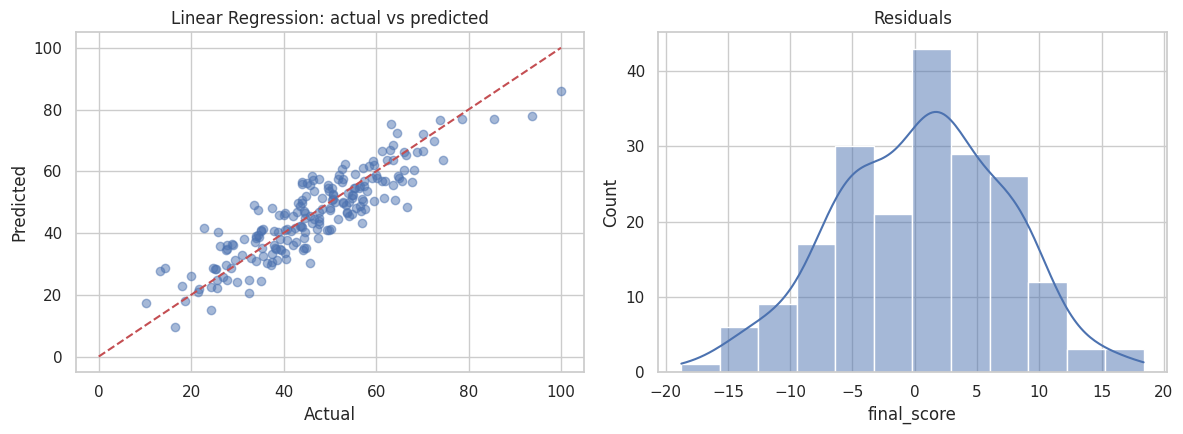

In [ ]:
pred = best_reg.predict(X_test)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(yr_test, pred, alpha=.5); ax[0].plot([0,100],[0,100],"r--")
ax[0].set(xlabel="Actual", ylabel="Predicted", title=f"{best_name}: actual vs predicted")
sns.histplot(yr_test - pred, kde=True, ax=ax[1]); ax[1].set_title("Residuals")
plt.tight_layout(); plt.show()

Logistic Regression: accuracy = 0.825
Random Forest: accuracy = 0.815

              precision    recall  f1-score   support

        Fail       0.84      0.85      0.84       118
        Pass       0.78      0.77      0.77        82

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



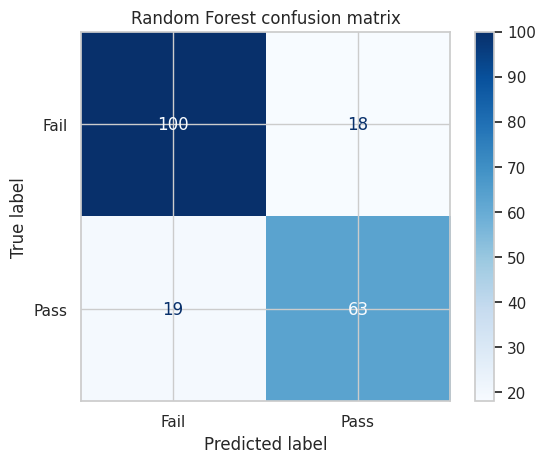

In [ ]:
clf = Pipeline([("prep", preprocess),
                ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))])
log = Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=1000))])
for name, m in [("Logistic Regression", log), ("Random Forest", clf)]:
    m.fit(X_train, yc_train)
    print(f"{name}: accuracy = {accuracy_score(yc_test, m.predict(X_test)):.3f}")

print()
print(classification_report(yc_test, clf.predict(X_test), target_names=["Fail","Pass"]))
ConfusionMatrixDisplay.from_estimator(clf, X_test, yc_test, display_labels=["Fail","Pass"], cmap="Blues")
plt.title("Random Forest confusion matrix"); plt.show()

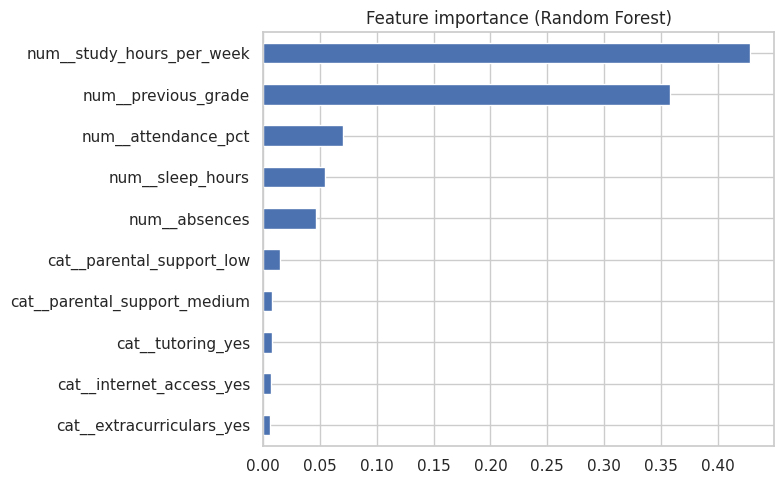

In [ ]:
rf = fitted_reg["Random Forest"]
names = rf.named_steps["prep"].get_feature_names_out()
imp = pd.Series(rf.named_steps["model"].feature_importances_, index=names).sort_values()
imp.plot(kind="barh", figsize=(8, 5), title="Feature importance (Random Forest)")
plt.tight_layout(); plt.show()

In [ ]:
def predict_student(study_hours, attendance, previous_grade, sleep, absences,
                    parental_support="medium", internet="yes", extracurriculars="no", tutoring="no"):
    student = pd.DataFrame([{
        "study_hours_per_week": study_hours, "attendance_pct": attendance,
        "previous_grade": previous_grade, "sleep_hours": sleep, "absences": absences,
        "parental_support": parental_support, "internet_access": internet,
        "extracurriculars": extracurriculars, "tutoring": tutoring}])
    score = float(np.clip(best_reg.predict(student)[0], 0, 100))
    p_pass = clf.predict_proba(student)[0, 1]
    print(f"Predicted final score: {score:.1f}/100")
    print(f"Probability of passing: {p_pass:.0%}")
    print("⚠️ At risk - consider early support." if p_pass < 0.6 else "✅ On track.")

predict_student(study_hours=15, attendance=92, previous_grade=75, sleep=7.5, absences=2, parental_support="high")
print("-"*40)
predict_student(study_hours=3, attendance=60, previous_grade=48, sleep=5, absences=15, parental_support="low", internet="no")

Predicted final score: 68.3/100
Probability of passing: 91%
✅ On track.
----------------------------------------
Predicted final score: 0.0/100
Probability of passing: 2%
⚠️ At risk - consider early support.


In [ ]:
import joblib
joblib.dump({"regressor": best_reg, "classifier": clf}, "student_predictor.joblib")
# from google.colab import files; files.download("student_predictor.joblib")  # uncomment to download

['student_predictor.joblib']